Lire data sur le fichier csv

In [1052]:
import pandas as pd
df=pd.read_csv(r'C:\Users\saido\Pycharm\Simplon\Brief 1\appartements-data-db-6872f0ba853ec096170787.csv')
print(df.head(3))

                                               title         price  \
0       CMN-MA-1752 - Appartement à vendre à Palmier  2 000 000 DH   
1  66370-Vente Appt à Casablanca Hay Hassani de 1...  1 195 000 DH   
2           Appartement à vendre 81 m² à Dar Bouazza  1 350 000 DH   

     city_name  salon  nb_rooms  nb_baths  surface_area  \
0   Casablanca    NaN       2.0       2.0         168.0   
1   Casablanca    NaN       2.0       2.0          98.0   
2  Dar Bouazza    1.0       2.0       2.0          81.0   

                                           equipment  \
0                  Ascenseur/Balcon/Parking/Terrasse   
1  Ascenseur/Balcon/Chauffage/Climatisation/Cuisi...   
2  Ascenseur/Balcon/Chauffage/Climatisation/Conci...   

                                                link  
0  https://www.avito.ma/fr/palmier/appartements/C...  
1  https://www.avito.ma/fr/hay_hassani/appartemen...  
2  https://www.avito.ma/fr/dar_bouazza/appartemen...  


Aperçu des données

In [1053]:
print('la taille du dataframe est de :', df.shape)
print('la description des données est :', df.describe())
print('les types de données sont :', df.dtypes)
print('les colonnes du dataframe sont :', df.columns)
print('le nombre des valeurs Nan',df.isnull().sum())

la taille du dataframe est de : (1773, 9)
la description des données est :              salon     nb_rooms     nb_baths   surface_area
count  1620.000000  1490.000000  1480.000000    1742.000000
mean      1.267284     2.379195     2.307432     174.933410
std       0.557539     0.667159     7.629128    2969.500693
min       0.000000     1.000000     0.000000       1.000000
25%       1.000000     2.000000     1.000000      71.000000
50%       1.000000     2.000000     2.000000      89.000000
75%       1.000000     3.000000     2.000000     114.750000
max       8.000000     7.000000   134.000000  123456.000000
les types de données sont : title            object
price            object
city_name        object
salon           float64
nb_rooms        float64
nb_baths        float64
surface_area    float64
equipment        object
link             object
dtype: object
les colonnes du dataframe sont : Index(['title', 'price', 'city_name', 'salon', 'nb_rooms', 'nb_baths',
       'surface_area', 

Détecter les valeurs manquantes

In [1054]:
df["price"] = df["price"].str.replace(r"[^\d]", "", regex=True).astype(float)
print('type de price est :', df['price'].dtypes)
print('le nombre des valeurs Nan',df.isnull().sum())

type de price est : float64
le nombre des valeurs Nan title             1
price           283
city_name         1
salon           153
nb_rooms        283
nb_baths        293
surface_area     31
equipment       371
link              0
dtype: int64


Étudier la distribution des variables (histogrammes)

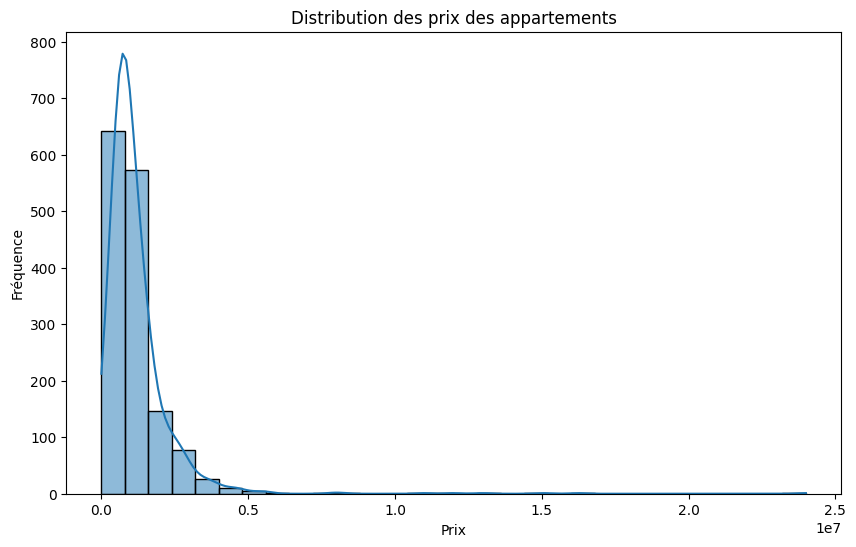

In [1055]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.histplot(df['price'], bins=30, kde=True)
plt.title('Distribution des prix des appartements')
plt.xlabel('Prix')
plt.ylabel('Fréquence')
plt.show()

In [1056]:
print('la description des données est :')
df.describe()

la description des données est :


,price,salon,nb_rooms,nb_baths,surface_area
count,1.490000e+03,1620.000000,1490.000000,1480.000000,1742.000000
mean,1.175197e+06,1.267284,2.379195,2.307432,174.933410
std,1.267979e+06,0.557539,0.667159,7.629128,2969.500693
min,3.500000e+01,0.000000,1.000000,0.000000,1.000000
25%,5.900000e+05,1.000000,2.000000,1.000000,71.000000
50%,8.800000e+05,1.000000,2.000000,2.000000,89.000000
75%,1.400000e+06,1.000000,3.000000,2.000000,114.750000
max,2.400000e+07,8.000000,7.000000,134.000000,123456.000000


Supprimer les valeurs Nan sur price

In [1057]:
# Affichage initial
df.head()

# Supprimer les lignes où la colonne 'price' contient des NaN
df.dropna(subset=["price"], inplace=True)

# Supprimer les doublons
df.drop_duplicates(inplace=True)

# Affichage final
df.head()
print('le nombre des valeurs Nan',df.isnull().sum())

le nombre des valeurs Nan title             0
price             0
city_name         0
salon           145
nb_rooms          0
nb_baths         10
surface_area     28
equipment       270
link              0
dtype: int64


In [1058]:
print('le nombre des valeurs Nan',df['salon'].isnull().sum())
df['salon'].fillna(df['salon'].mean(), inplace=True)
print('le nombre des valeurs Nan',df['salon'].isnull().sum())

le nombre des valeurs Nan 145
le nombre des valeurs Nan 0


C:\Users\saido\AppData\Local\Temp\ipykernel_25544\1785508659.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['salon'].fillna(df['salon'].mean(), inplace=True)


Détecter les outliers

In [1059]:
# Détection des valeurs extrêmes pour la colonne 'price'
col = "price"
q1 = df[col].quantile(0.25)
q3 = df[col].quantile(0.75)
iqr = q3 - q1

borne_min = q1 - 1.5 * iqr
borne_max = q3 + 1.5 * iqr

outliers = df[(df[col] < borne_min) | (df[col] > borne_max)]

print("Les valeurs extrêmes dans la colonne 'price' sont :")
print(outliers[col])


Les valeurs extrêmes dans la colonne 'price' sont :
4       3100000.0
5       3200000.0
23      5500000.0
65      2850000.0
78      2900000.0
          ...    
1612    3300000.0
1621    3000000.0
1638    3600000.0
1721    3800000.0
1754    3300000.0
Name: price, Length: 93, dtype: float64


Supprimer les outliers

In [1060]:
# Suppression des outliers uniquement pour la colonne 'price'
q1 = df["price"].quantile(0.25)
q3 = df["price"].quantile(0.75)
iqr = q3 - q1

min_val = q1 - 1.5 * iqr
max_val = q3 + 1.5 * iqr

# Filtrer les lignes où 'price' est dans l'intervalle acceptable
df = df[(df["price"] >= min_val) & (df["price"] <= max_val)]

print("Suppression des outliers sur la colonne 'price' réussie !")
print(df["price"])


Suppression des outliers sur la colonne 'price' réussie !
0       2000000.0
1       1195000.0
2       1350000.0
3        900000.0
6        760000.0
          ...    
1763     985000.0
1764     730000.0
1765     300000.0
1766       3500.0
1767     700000.0
Name: price, Length: 1361, dtype: float64


verifier la supprition des outliers

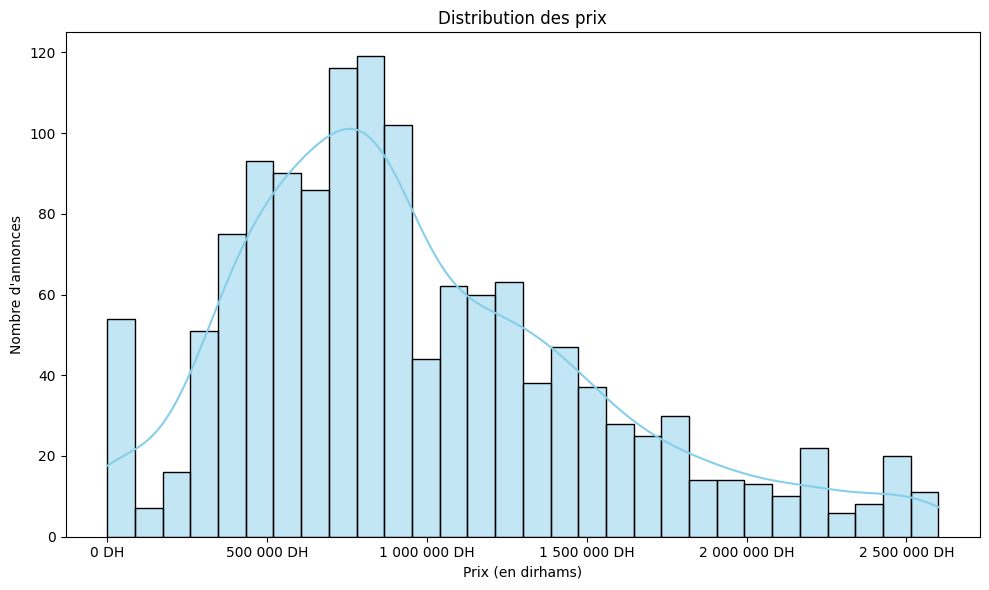

In [1061]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick

plt.figure(figsize=(10, 6))
sns.histplot(df["price"].dropna(), kde=True, bins=30, color="skyblue")
plt.title("Distribution des prix")
plt.xlabel("Prix (en dirhams)")
plt.ylabel("Nombre d'annonces")
plt.gca().xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"{int(x):,}".replace(",", " ") + " DH"))
plt.tight_layout()
plt.show()


Quelle est la corrélation entre le prix et les autres variables ?

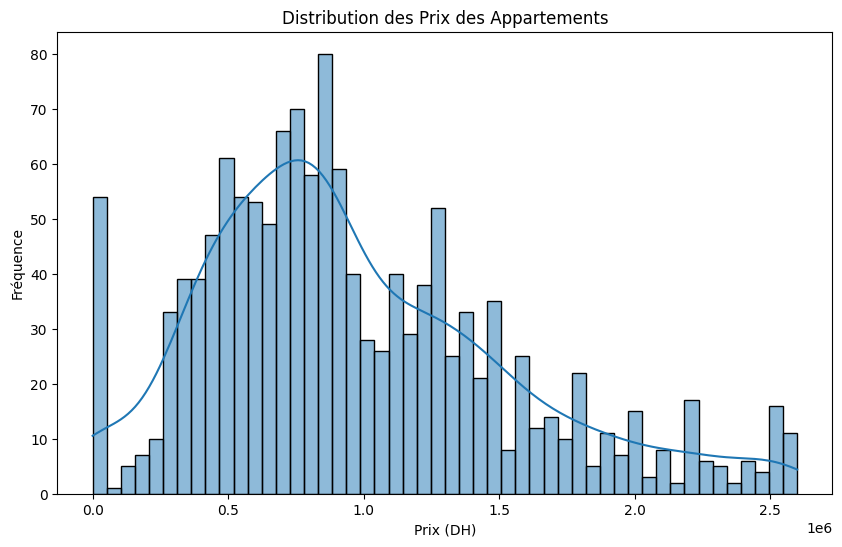

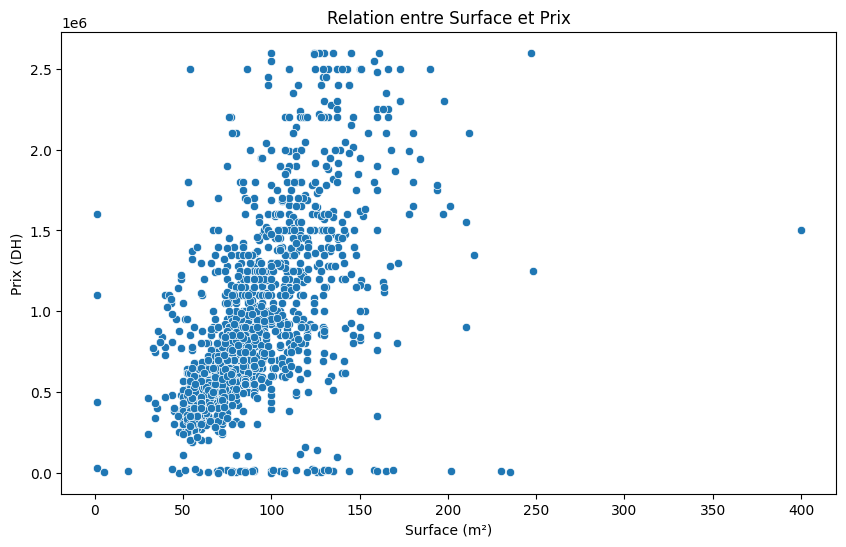

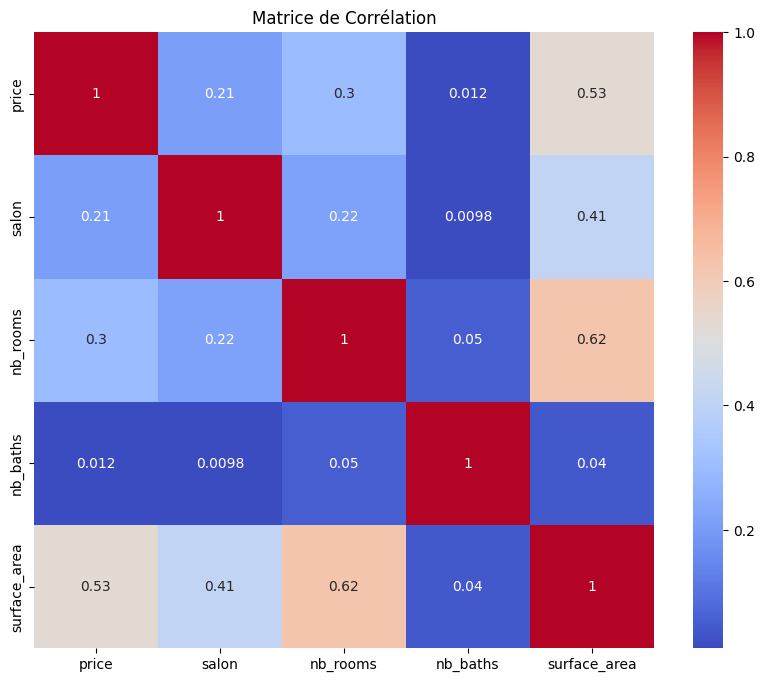

In [1062]:
# Distribution des prix
plt.figure(figsize=(10,6))
sns.histplot(df['price'], bins=50, kde=True)
plt.title('Distribution des Prix des Appartements')
plt.xlabel('Prix (DH)')
plt.ylabel('Fréquence')
plt.show()

# Relation surface/prix
plt.figure(figsize=(10,6))
sns.scatterplot(x='surface_area', y='price', data=df)
plt.title('Relation entre Surface et Prix')
plt.xlabel('Surface (m²)')
plt.ylabel('Prix (DH)')
plt.show()

# Matrice de corrélation
corr_matrix = df.select_dtypes(include=['float64']).corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Matrice de Corrélation')
plt.show()

 Détection des valeurs manquantes

In [1063]:
# Pour voir combien de valeurs manquantes par colonne
print(df.isnull().sum())

# Pourcentage de valeurs manquantes
print((df.isnull().sum() / len(df)) * 100)


title             0
price             0
city_name         0
salon             0
nb_rooms          0
nb_baths         10
surface_area     28
equipment       261
link              0
dtype: int64
title            0.000000
price            0.000000
city_name        0.000000
salon            0.000000
nb_rooms         0.000000
nb_baths         0.734754
surface_area     2.057311
equipment       19.177076
link             0.000000
dtype: float64


Gestion des équipements

In [1064]:
# Supposons que la colonne 'equipment' contient des chaînes comme "Ascenseur,Balcon,Climatisation"
# 1. Remplacer les valeurs manquantes par une chaîne vide (si nécessaire)
df["equipment"] = df["equipment"].fillna("")

# 2. Extraire chaque équipement dans une colonne binaire
equipment_dummies = df["equipment"].str.get_dummies("/")

# 3. Concaténer au DataFrame original
df = pd.concat([df.drop("equipment", axis=1), equipment_dummies], axis=1)

# Afficher les premières lignes
df.head()


,title,price,city_name,salon,nb_rooms,nb_baths,surface_area,link,Ascenseur,Balcon,Chauffage,Climatisation,Concierge,Cuisine Équipée,Duplex,Meublé,Parking,Sécurité,Terrasse
0,CMN-MA-1752 - Appartement à vendre à Palmier,2000000.0,Casablanca,1.270435,2.0,2.0,168.0,https://www.avito.ma/fr/palmier/appartements/C...,1,1,0,0,0,0,0,0,1,0,1
1,66370-Vente Appt à Casablanca Hay Hassani de 1...,1195000.0,Casablanca,1.270435,2.0,2.0,98.0,https://www.avito.ma/fr/hay_hassani/appartemen...,1,1,1,1,0,1,0,0,1,0,0
2,Appartement à vendre 81 m² à Dar Bouazza,1350000.0,Dar Bouazza,1.000000,2.0,2.0,81.0,https://www.avito.ma/fr/dar_bouazza/appartemen...,1,1,1,1,1,1,1,0,1,1,1
3,63860-Vente Appt à Casablanca Quartier Bd Med ...,900000.0,Casablanca,1.270435,1.0,1.0,56.0,https://www.avito.ma/fr/centre_ville/apparteme...,1,0,1,1,0,1,0,1,1,1,1
6,Appartement à vendre 98 m² à Marrakech,760000.0,Marrakech,1.000000,3.0,3.0,98.0,https://www.avito.ma/fr/akioud/appartements/Ap...,1,1,0,0,1,1,0,0,1,1,0


In [1065]:

df.drop(['link', 'title'], axis=1, inplace=True)


In [1066]:
df.head()
df2 = df.copy()
df2.head()

,price,city_name,salon,nb_rooms,nb_baths,surface_area,Ascenseur,Balcon,Chauffage,Climatisation,Concierge,Cuisine Équipée,Duplex,Meublé,Parking,Sécurité,Terrasse
0,2000000.0,Casablanca,1.270435,2.0,2.0,168.0,1,1,0,0,0,0,0,0,1,0,1
1,1195000.0,Casablanca,1.270435,2.0,2.0,98.0,1,1,1,1,0,1,0,0,1,0,0
2,1350000.0,Dar Bouazza,1.000000,2.0,2.0,81.0,1,1,1,1,1,1,1,0,1,1,1
3,900000.0,Casablanca,1.270435,1.0,1.0,56.0,1,0,1,1,0,1,0,1,1,1,1
6,760000.0,Marrakech,1.000000,3.0,3.0,98.0,1,1,0,0,1,1,0,0,1,1,0


renomer les ville

In [1067]:
# Uniformisation des noms de villes
city_mapping = {
    'الدار البيضاء': 'Casablanca',
    'الرباط': 'Rabat',
    'فاس': 'Fès',
    'مراكش': 'Marrakech',
    'مكناس': 'Meknès',
    'طنجة': 'Tanger',
    'أكادير': 'Agadir',
    'وجدة': 'Oujda',
    'تطوان': 'Tétouan',
    'القنيطرة': 'Kénitra',
    'المحمدية': 'Mohammedia',
    'الناظور': 'Nador',
    'تمارة': 'Témara',
    'خريبكة': 'Khouribga',
    'بني ملال': 'Beni Mellal',
    'الجديدة': 'El Jadida',
    'سطات': 'Settat',
    'بركان': 'Berkane',
    'تازة': 'Taza',
    'قلعة السراغنة': 'Kelaat Sraghna',
    'الفقيه بن صالح': 'Fquih Ben Salah',
    'آسفي': 'Safi',
    'تاوريرت': 'Taourirt',
    'الرشيدية': 'Errachidia',
    'سيدي قاسم': 'Sidi Kacem',
    'سلا': 'Salé',
    'العيون': 'Laâyoune',
    'الداخلة': 'Dakhla',
    'تزنيت': 'Tiznit',
    'الحسيمة': 'Al Hoceïma',
    'الصويرة': 'Essaouira',
    'ورزازات': 'Ouarzazate',
    'تيفلت': 'Tiflet',
    'تاونات': 'Taounate',
    'جرسيف': 'Guercif',
    'اليوسفية': 'Youssoufia',
    'زاكورة': 'Zagora',
    'شيشاوة': 'Chichaoua',
    'بن جرير': 'Ben Guerir',
    'صفرو': 'Sefrou',
    'السمارة': 'Smara'
}
df2['city_name'] = df2['city_name'].replace(city_mapping)
df2['city_name'] = df2['city_name'].fillna('Unknown')
df2.head()

,price,city_name,salon,nb_rooms,nb_baths,surface_area,Ascenseur,Balcon,Chauffage,Climatisation,Concierge,Cuisine Équipée,Duplex,Meublé,Parking,Sécurité,Terrasse
0,2000000.0,Casablanca,1.270435,2.0,2.0,168.0,1,1,0,0,0,0,0,0,1,0,1
1,1195000.0,Casablanca,1.270435,2.0,2.0,98.0,1,1,1,1,0,1,0,0,1,0,0
2,1350000.0,Dar Bouazza,1.000000,2.0,2.0,81.0,1,1,1,1,1,1,1,0,1,1,1
3,900000.0,Casablanca,1.270435,1.0,1.0,56.0,1,0,1,1,0,1,0,1,1,1,1
6,760000.0,Marrakech,1.000000,3.0,3.0,98.0,1,1,0,0,1,1,0,0,1,1,0


Identifier les variables catégorielles

In [1068]:
colonnes_categor = df2.select_dtypes(include=['object', 'category']).columns
print("Colonnes catégorielles :", colonnes_categor.tolist())

Colonnes catégorielles : ['city_name']


In [1069]:
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
import joblib
import numpy as np

Encodage par étiquettes (Label Encoding)
et normalisation

In [1070]:
df2["city_name"] = df2["city_name"].fillna("Unknown")
le = LabelEncoder()
df2["city_name"] = le.fit_transform(df2["city_name"])
joblib.dump(le, "label_encoder.save")
# Liste des colonnes numériques à normaliser
numerical_cols = ['salon', 'nb_rooms', 'nb_baths', 'surface_area']

# Normalisation
scaler = StandardScaler()
df2[numerical_cols] = scaler.fit_transform(df2[numerical_cols])
df2.head()

,price,city_name,salon,nb_rooms,nb_baths,surface_area,Ascenseur,Balcon,Chauffage,Climatisation,Concierge,Cuisine Équipée,Duplex,Meublé,Parking,Sécurité,Terrasse
0,2000000.0,12,0.069319,-0.531727,-0.033101,2.253809,1,1,0,0,0,0,0,0,1,0,1
1,1195000.0,12,0.069319,-0.531727,-0.033101,0.154097,1,1,1,1,0,1,0,0,1,0,0
2,1350000.0,14,-0.524192,-0.531727,-0.033101,-0.355833,1,1,1,1,1,1,1,0,1,1,1
3,900000.0,12,0.069319,-2.081365,-0.163477,-1.105730,1,0,1,1,0,1,0,1,1,1,1
6,760000.0,30,-0.524192,1.017910,0.097276,0.154097,1,1,0,0,1,1,0,0,1,1,0


Quelle est la cible et quelles sont les features ?



Sélection des variables explicatives corrélées au prix

In [1071]:
# Corrélation avec le prix
correlations = df2.corr(numeric_only=True)["price"].abs().sort_values(ascending=False)
print(correlations)

# Choisir les colonnes avec une corrélation > 0.15 (exclure 'price')
selected_features = correlations[correlations > 0.15].drop("price").index.tolist()
print("Colonnes sélectionnées :", selected_features)


price              1.000000
surface_area       0.530967
Ascenseur          0.343350
nb_rooms           0.296642
Parking            0.252405
Climatisation      0.230157
Concierge          0.220562
salon              0.207495
Chauffage          0.194670
Terrasse           0.194079
Balcon             0.141227
Sécurité           0.130239
Cuisine Équipée    0.123867
Meublé             0.077917
city_name          0.070820
Duplex             0.064812
nb_baths           0.011976
Name: price, dtype: float64
Colonnes sélectionnées : ['surface_area', 'Ascenseur', 'nb_rooms', 'Parking', 'Climatisation', 'Concierge', 'salon', 'Chauffage', 'Terrasse']


In [1072]:
df2["price_per_m2"] = df2["price"] / df2["surface_area"]
df2["total_pieces"] = df2["salon"] + df2["nb_rooms"]
df2["is_equipped"] = (df2["Climatisation"] + df2["Ascenseur"] + df2["Balcon"] > 0).astype(int)

In [1073]:
correlations = df2.corr(numeric_only=True)["price"].abs().sort_values(ascending=False)
selected_features = correlations[correlations > 0.15].drop("price").index.tolist()
print("Colonnes sélectionnées :", selected_features)

Colonnes sélectionnées : ['surface_area', 'Ascenseur', 'total_pieces', 'nb_rooms', 'Parking', 'Climatisation', 'is_equipped', 'Concierge', 'salon', 'Chauffage', 'Terrasse']


Séparation des données

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

X = df2[selected_features]
y = df2["price"]

imputer = SimpleImputer(strategy='mean')
X_imputed = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

X_train, X_test, y_train, y_test = train_test_split(X_imputed, y, test_size=0.2, random_state=42)

models = {
    "LinearRegression": LinearRegression(),
    "RandomForest": RandomForestRegressor(random_state=42),
    "GradientBoosting": GradientBoostingRegressor(random_state=42),
    "SVR": SVR(),
    "XGBoost": XGBRegressor(random_state=42),
    "LightGBM": LGBMRegressor(random_state=42)
}

results = {}
cv = KFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    results[name] = {
        "MAE": mean_absolute_error(y_test, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, y_pred)),
        "R2": r2_score(y_test, y_pred),
        "CV_R2": cross_val_score(model, X_imputed, y, cv=cv, scoring='r2').mean()
    }

df_results = pd.DataFrame(results).T.sort_values("CV_R2", ascending=False)
print(df_results)

best_model_name = df_results.index[0]
best_model = models[best_model_name]
print(f"\nLe meilleur modèle est : {best_model_name}")
print(f"Coefficient de détermination (R² en validation croisée) : {df_results.loc[best_model_name, 'CV_R2'] * 100:.2f}%")


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000093 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 161
[LightGBM] [Info] Number of data points in the train set: 1088, number of used features: 11
[LightGBM] [Info] Start training from score 965139.773897
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000077 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 161
[LightGBM] [Info] Number of data points in the train set: 1088, number of used features: 11
[LightGBM] [Info] Start training from score 965139.773897
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000058 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not

In [1075]:
# Étape 6 : Identifier le meilleur modèle selon CV_R2
cv_r2_list = [scores["CV_R2"] for scores in results.values()]
best_idx = int(np.argmax(cv_r2_list))
best_model_name = list(models.keys())[best_idx]
best_model = list(models.values())[best_idx]

print(f"\n>>> ✅ Le meilleur modèle est : {best_model_name}")
print(f">>> Son score R2 (validation croisée) : {cv_r2_list[best_idx]*100:.2f}%")



>>> ✅ Le meilleur modèle est : GradientBoosting
>>> Son score R2 (validation croisée) : 40.77%


Optimisation hyperparamètres pour le meilleur modèle

In [1076]:
if best_model_name == "LightGBM":
    param_grid = {
        'n_estimators': [100, 300, 500],
        'learning_rate': [0.01, 0.05, 0.1],
        'max_depth': [3, 5, 10]
    }
    grid_search = GridSearchCV(best_model, param_grid, cv=5, scoring='r2', n_jobs=-1)
    grid_search.fit(X_train, y_train)

    best_model = grid_search.best_estimator_

    y_pred = best_model.predict(X_test)

    print("\n✅ Résultats après tuning :")
    print(f"MAE  : {mean_absolute_error(y_test, y_pred):.2f}")
    print(f"RMSE : {np.sqrt(mean_squared_error(y_test, y_pred)):.2f}")
    print(f"R²   : {r2_score(y_test, y_pred) * 100:.2f}%")


In [1077]:
import pandas as pd

df_results = pd.DataFrame(results).T.sort_values("CV_R2", ascending=False)
print(df_results)


                            MAE           RMSE        R2     CV_R2
GradientBoosting  319800.663609  451767.314555  0.357373  0.407656
LightGBM          323055.481830  452378.894329  0.355632  0.356021
LinearRegression  329690.533732  453541.658486  0.352315  0.338779
RandomForest      318632.266945  454519.234637  0.349520  0.331985
XGBoost           334911.973100  506486.336702  0.192273  0.220980
SVR               415272.482979  575877.940924 -0.044216 -0.043977


Sauvegarde du meilleur modèle

In [1078]:
joblib.dump(best_model, "model.pkl")
print("Modèle sauvegardé avec succès dans 'model.pkl'")


Modèle sauvegardé avec succès dans 'model.pkl'


nouvelle entrenment

Affichage des scores(Évaluation)

In [1079]:
for name, scores in results.items():
    print(f"\n{name}:")
    for metric, value in scores.items():
        print(f"  {metric}: {value:.4f}")



LinearRegression:
  MAE: 329690.5337
  RMSE: 453541.6585
  R2: 0.3523
  CV_R2: 0.3388

RandomForest:
  MAE: 318632.2669
  RMSE: 454519.2346
  R2: 0.3495
  CV_R2: 0.3320

GradientBoosting:
  MAE: 319800.6636
  RMSE: 451767.3146
  R2: 0.3574
  CV_R2: 0.4077

SVR:
  MAE: 415272.4830
  RMSE: 575877.9409
  R2: -0.0442
  CV_R2: -0.0440

XGBoost:
  MAE: 334911.9731
  RMSE: 506486.3367
  R2: 0.1923
  CV_R2: 0.2210

LightGBM:
  MAE: 323055.4818
  RMSE: 452378.8943
  R2: 0.3556
  CV_R2: 0.3560


In [1080]:
df2.head()

,price,city_name,salon,nb_rooms,nb_baths,surface_area,Ascenseur,Balcon,Chauffage,Climatisation,Concierge,Cuisine Équipée,Duplex,Meublé,Parking,Sécurité,Terrasse,price_per_m2,total_pieces,is_equipped
0,2000000.0,12,0.069319,-0.531727,-0.033101,2.253809,1,1,0,0,0,0,0,0,1,0,1,8.873866e+05,-0.462408,1
1,1195000.0,12,0.069319,-0.531727,-0.033101,0.154097,1,1,1,1,0,1,0,0,1,0,0,7.754837e+06,-0.462408,1
2,1350000.0,14,-0.524192,-0.531727,-0.033101,-0.355833,1,1,1,1,1,1,1,0,1,1,1,-3.793919e+06,-1.055919,1
3,900000.0,12,0.069319,-2.081365,-0.163477,-1.105730,1,0,1,1,0,1,0,1,1,1,1,-8.139422e+05,-2.012046,1
6,760000.0,30,-0.524192,1.017910,0.097276,0.154097,1,1,0,0,1,1,0,0,1,1,0,4.931947e+06,0.493718,1


Création d’une API Flask